# 돌봄부담 학습 데이터셋 — 다차원 EDA

**대상**: `ABC8pioneer3.cb_dataset_v1` (MariaDB) · 3,000가구
**원천**: 2024 발달장애인 일과 삶 실태조사 (`2024_care_burden_std09`)
**근거 문서**: `docs/학습데이터셋-컬럼정의.md` · `specs/001-care-burden-map/spec.md` · Constitution v1.0.0

이 노트북은 **DB에 직접 접속해** 열 개 분석 차원을 순서대로 그린다. 파일 사본이나 CSV를 두지 않으므로
원천이 바뀌면 재실행만으로 결과가 갱신된다.

| # | 차원 | 묻는 것 |
|---|---|---|
| 0 | 데이터 개요 | 행·열·분할이 문서와 일치하는가 |
| 0.5 | **배제 컬럼 검증** | **Data Leakage로 빼기로 한 6개가 정말 빠져 있는가** |
| 1 | 예측 대상 분포 | 5개 부담 구간이 얼마나 불균형한가 |
| 2 | 결측 구조 | 결측은 누락인가, 분기 문항의 "해당 없음"인가 |
| 3 | 변수 유형 구성 | 38개 설명변수가 어떤 척도로 이루어져 있는가 |
| 4 | 단독 설명력 | 변수 하나가 target 불확실성의 몇 %를 설명하는가 |
| 5 | 순서형 변수 × 부담 | 응답 수준이 오를수록 부담 분포가 단조롭게 움직이는가 |
| 6 | 연속형 변수 × 부담 | 보호자 연령·장애 의심 시점이 부담과 어떻게 얽히는가 |
| 7 | 가구주 유형 | 가구 구조별 고부담군 비율이 갈리는가 |
| 8 | 보조 돌봄제공자 역설 | 돌볼 사람이 없으면 정말 부담이 큰가 |
| 9 | 변수 간 연관 구조 | 설명변수끼리 중복되어 있는가 |
| 10 | 분할 무결성 | train/test·cv_fold 층화가 유지되는가 |

> **척도 방향 주의** — `care_burden`은 **1이 최고부담, 5가 부담 없음**이다. 숫자가 작을수록 부담이 크다.
> 이 노트북의 모든 그래프는 진한 색 = 고부담으로 통일한다.

## 0. 환경 준비

필요한 패키지는 `pandas`, `numpy`, `matplotlib`, `pymysql` 넷뿐이다. Docker·컨테이너를 쓰지 않고
프로젝트 폴더 안에서 코드로만 전개한다(Constitution 원칙 V).

```bash
python3 -m pip install pandas numpy matplotlib pymysql
```

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import pymysql
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ── 한글 폰트 ────────────────────────────────────────────────
_available = {f.name for f in mpl.font_manager.fontManager.ttflist}
for _cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
    if _cand in _available:
        mpl.rcParams["font.family"] = _cand
        break
else:
    print("한글 폰트를 찾지 못했습니다. 축 라벨이 깨질 수 있습니다.")
mpl.rcParams["axes.unicode_minus"] = False

# ── 팔레트 ───────────────────────────────────────────────────
# 검증된 기본 팔레트. 범주형 색은 고정 순서로만 배정하고 순환시키지 않는다.
SURFACE   = "#fcfcfb"
INK       = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
             "grid": "#e1e0d9", "axis": "#c3c2b7"}
CAT       = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
             "#008300", "#4a3aa7", "#e34948"]           # 범주형 고정 순서
SEQ_HUE   = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6",
             "#256abf", "#1c5cab", "#184f95", "#104281"] # 단일 색상 순차 램프
CRITICAL  = "#d03b3b"                                    # 경고 표시 전용(계열색으로 쓰지 않음)

# 부담 구간 = 순서가 있는 크기이므로 단일 색상 순차 램프. 진할수록 고부담.
BURDEN_RAMP = ["#104281", "#1c5cab", "#2a78d6", "#5598e7", "#86b6ef"]
BURDEN_NAME = {1: "최고부담군", 2: "고부담군", 3: "중간부담군", 4: "저부담군", 5: "부담 없음"}
SEQ_CMAP    = LinearSegmentedColormap.from_list("seq_blue", SEQ_HUE)

mpl.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "font.size": 10,
    "axes.edgecolor": INK["axis"], "axes.labelcolor": INK["secondary"],
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "text.color": INK["primary"], "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlecolor": INK["primary"], "axes.titlepad": 14,
    "legend.frameon": False, "figure.autolayout": False,
})


def style(ax, xgrid=False, ygrid=False):
    """축을 후퇴시키는 공통 처리 — 격자·축선은 데이터보다 뒤로."""
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(INK["axis"])
        ax.spines[side].set_linewidth(0.8)
    if xgrid:
        ax.xaxis.grid(True, color=INK["grid"], linewidth=0.8)
    if ygrid:
        ax.yaxis.grid(True, color=INK["grid"], linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax


def subtitle(fig, text, y=0.955):
    fig.text(0.0, y, text, ha="left", va="bottom", fontsize=9.5, color=INK["secondary"])


print("matplotlib", mpl.__version__, "| pandas", pd.__version__, "| font", mpl.rcParams["font.family"][0])

matplotlib 3.11.0 | pandas 2.3.3 | font Apple SD Gothic Neo


## 1. 데이터베이스 연결 정보

팀 MariaDB(`MariaDB A`)에 외부 접속으로 붙는다. 아래 값이 이 노트북의 유일한 데이터 출처다.

| 항목 | 값 |
|---|---|
| 호스트 | `mis.iptime.org` (내부망: `192.168.0.91`) |
| 포트 | `13306` (내부망: `3306`) |
| 사용자 | `pioneer3` |
| 데이터베이스 | `ABC8pioneer3` |
| 드라이버 | `pymysql` (순수 파이썬, 빌드 도구 불필요) |

터미널에서 같은 대상에 붙을 때:

```bash
mysql -h mis.iptime.org -P 13306 -u pioneer3 -ppioneer26 ABC8pioneer3
```

In [2]:
# ── 데이터베이스 접속 정보 ────────────────────────────────────
DB_CONFIG = {
    "host":     "mis.iptime.org",   # 내부망에서는 "192.168.0.91"
    "port":     13306,              # 내부망에서는 3306
    "user":     "pioneer3",
    "password": "pioneer26",
    "database": "ABC8pioneer3",
    "charset":  "utf8mb4",
}


def query(sql, params=None):
    """DB에서 한 번 읽고 즉시 연결을 닫는다. 노트북이 커넥션을 붙들지 않게 한다."""
    con = pymysql.connect(**DB_CONFIG)
    try:
        return pd.read_sql(sql, con, params=params)
    finally:
        con.close()


# 연결 확인 — 대상 객체 4종이 모두 보여야 한다.
objects = query("""
    SELECT TABLE_NAME AS 객체, TABLE_TYPE AS 유형, TABLE_ROWS AS 행수_추정
    FROM information_schema.TABLES
    WHERE TABLE_SCHEMA = %s
    ORDER BY TABLE_NAME
""", params=(DB_CONFIG["database"],))
display(objects)

,객체,유형,행수_추정
0,2024_care_burden_std09,BASE TABLE,2961.0
1,cb_dataset_v1,BASE TABLE,3040.0
2,cb_feature_meta_v1,BASE TABLE,38.0
3,services_with_coords_std09,BASE TABLE,1258.0
4,v_cb_linear_v1,VIEW,NaN
5,v_cb_tree_v1,VIEW,NaN


## 2. 데이터 적재와 라벨 사전

`cb_dataset_v1`(42열)과 변수 메타 `cb_feature_meta_v1`(38행)을 함께 읽는다.
메타 테이블의 `scale_note`에는 각 변수의 **응답값 의미와 척도 방향**이 들어 있어, 그래프 축 설명에 그대로 쓴다.

한글 라벨은 공식 매핑표(`docs/2024csv_column_mapping.xlsx`) 기준이며 `docs/학습데이터셋-컬럼정의.md`와 동일하다.

In [3]:
df   = query("SELECT * FROM cb_dataset_v1")
meta = query("SELECT * FROM cb_feature_meta_v1").set_index("feature")
meta["missing_pct"] = meta["missing_pct"].astype(float)

FEATURES = list(meta.index)                 # 설명변수 38개
TRAIN    = df[df["split"] == "train"].copy()
TEST     = df[df["split"] == "test"].copy()

# ── 컬럼 한글 라벨 (매핑표 기준) ──────────────────────────────
LABEL = {
    "care_burden": "돌봄부담 수준(target)",
    "help_needed_hours": "도움필요시간", "daily_routine_satisfaction": "일과만족도",
    "understands_work_meaning": "근로의미이해정도", "can_work_standard_job": "통상근로가능여부",
    "job_ability_mobility": "직업적능력_이동성", "job_ability_strength": "직업적능력_체력",
    "school_helpfulness": "학교교육도움정도", "final_school": "최종학교",
    "has_job_skill_cert": "전문기술자격보유여부", "completion_status": "이수상태",
    "overall_health": "전반적건강상태", "has_chronic_disease": "만성질병여부",
    "health_change_yoy": "작년대비건강변화", "early_aging": "조기노화여부",
    "exercises_regularly": "평소운동여부", "is_employed": "취업여부",
    "employment_status": "종사상지위", "severe_dd_job_willingness": "최중증발달장애인취업의사",
    "wants_person_employed": "당사자취업희망여부", "past_employment_exp": "과거취업경험",
    "last_job_quit_reason": "마지막일자리퇴사이유", "past_job_count": "과거일자리개수",
    "wanted_to_stay_at_last_job": "퇴사당시계속근무희망여부", "caregiver_age": "주보호자연령",
    "family_support_for_employment": "취업에대한가족지지정도", "household_head_type": "가구주 유형",
    "relation_to_person": "당사자와의관계", "primary_caregiver_type": "주보호자유형",
    "household_size": "가구원수", "lives_with_mother": "어머니동거여부",
    "lives_with_father": "아버지동거여부", "secondary_caregiver_type": "부보호자유형",
    "lives_with_person": "당사자동거여부", "caregiver_employment_status": "주보호자취업상태",
    "caregiver_gender": "주보호자성별", "age_disability_suspected": "장애의심시작나이",
    "person_marital_status": "당사자혼인상태", "person_gender": "당사자성별",
}

# ── 명목형 변수의 값 라벨 (메타 scale_note 기준) ───────────────
VALUE_LABEL = {
    "household_head_type": {1: "아버지", 2: "어머니", 3: "장애인 당사자", 4: "형제자매",
                            5: "조부모", 6: "배우자", 7: "자녀", 8: "기타"},
    "primary_caregiver_type": {1: "아버지", 2: "어머니", 3: "형제자매", 4: "조부모",
                               5: "배우자", 6: "자녀", 7: "그외 가족", 8: "비가족"},
    "secondary_caregiver_type": {1: "아버지", 2: "어머니", 3: "형제자매", 4: "조부모",
                                 5: "배우자", 6: "자녀", 7: "그외 가족", 8: "비가족", 9: "없음"},
    "relation_to_person": {1: "아버지", 2: "어머니", 3: "형제자매", 4: "조부모", 5: "배우자",
                           6: "자녀", 7: "그외 가족", 8: "비가족 보호자"},
    "is_employed": {1: "취업", 2: "미취업"},
    "caregiver_employment_status": {1: "취업", 2: "미취업"},
}

def lab(col):        # 축 제목용
    return LABEL.get(col, col)

def note(col):       # 척도 방향 설명 (DB의 scale_note를 그대로 인용)
    return meta.loc[col, "scale_note"] if col in meta.index else ""

print(f"전체 {len(df):,}행 · {df.shape[1]}열 | train {len(TRAIN):,} · test {len(TEST):,} | 설명변수 {len(FEATURES)}개")

전체 3,000행 · 43열 | train 2,398 · test 602 | 설명변수 38개


## 차원 0 — 데이터 개요

숫자 몇 개가 그래프보다 낫다. 문서(`docs/학습데이터셋-컬럼정의.md`)가 기록한 값과 DB의 실제 값이 같은지부터 확인한다.

In [4]:
overview = pd.DataFrame([
    ("전체 행",        f"{len(df):,}",                       "3,000"),
    ("train",          f"{len(TRAIN):,}",                    "2,398"),
    ("test",           f"{len(TEST):,}",                     "602"),
    ("열 수",          f"{df.shape[1]}",                     "43 = 메타 4 + target 1 + 설명변수 38"),
    ("설명변수",       f"{len(FEATURES)}",                   "38"),
    ("cv_fold 채워짐", f"{df['cv_fold'].notna().sum():,}",   "2,398 (train만)"),
    ("row_id 중복",    f"{df['row_id'].duplicated().sum()}", "0"),
    ("row_key 중복",   f"{df['row_key'].duplicated().sum()}","0"),
    ("target 결측",    f"{df['care_burden'].isna().sum()}",  "0"),
], columns=["항목", "실측", "문서 기록"])
display(overview.style.hide(axis="index"))
print("※ 컬럼정의서 본문은 열 수를 42로 적었으나 실제는 43이다(4+1+38). 문서 쪽 합산 오기다.")

항목,실측,문서 기록
전체 행,"3,000","3,000"
train,"2,398","2,398"
test,602,602
열 수,43,43 = 메타 4 + target 1 + 설명변수 38
설명변수,38,38
cv_fold 채워짐,"2,398","2,398 (train만)"
row_id 중복,0,0
row_key 중복,0,0
target 결측,0,0


※ 컬럼정의서 본문은 열 수를 42로 적었으나 실제는 43이다(4+1+38). 문서 쪽 합산 오기다.


## 차원 0.5 — 배제 컬럼 검증 (Data Leakage)

target `care_burden`은 원 문항 **I13**이다. 아래 6개는 같은 I 블록에 속하거나 동일 구성개념을 측정하므로
**모델 입력과 설문 문항 양쪽에서 전면 배제**하기로 했다(FR-004b, Constitution 원칙 I).

배제는 이 노트북이 아니라 **`cb_dataset_v1`을 만들 때 이미 수행**되었다. 원천 45열에서 6열을 빼
설명변수 38개가 남았고, 여기에 메타 4열과 target을 더해 43열이 된다.

이 셀은 그 배제가 실제로 유지되고 있는지 **매 실행마다 검사**한다. 하나라도 남아 있으면
`AssertionError`로 노트북이 멈춘다 — 이후의 모든 분석이 오염되기 때문이다.

In [5]:
LEAKAGE = pd.DataFrame([
    ("caregiver_life_satisfaction", "보호자삶만족도",           "I14",
     "target과 동일 구성개념. 이것으로 부담을 예측하면 동어반복이 되어 진단 도구의 존재 이유가 사라짐"),
    ("care_difficulty_top1",        "돌봄어려움1순위",          "I10",
     "부담이 이미 있음을 전제하고 그 원인을 묻는 문항"),
    ("needed_care_service_type",    "필요한통합돌봄서비스유형", "I12_1",
     "부담 판단의 결과로 도출되는 응답"),
    ("work_care_gap_hours",         "월평균돌봄공백시간",       "I11_H",
     "target과 동일 I 블록. 돌봄으로 인한 결과 지표"),
    ("work_care_gap_exp",           "근로중돌봄공백경험",       "I11",
     "target과 동일 I 블록"),
    ("integrated_care_awareness",   "통합돌봄제도인지도",       "I12",
     "target과 동일 I 블록"),
], columns=["컬럼", "한글 라벨", "원 문항", "배제 사유"])

LK_COLS  = list(LEAKAGE["컬럼"])
LK_LABEL = dict(zip(LEAKAGE["컬럼"], LEAKAGE["한글 라벨"]))

src_cols = set(query("SELECT * FROM `2024_care_burden_std09` LIMIT 0").columns)
LEAKAGE["원천 테이블"] = ["있음" if c in src_cols else "없음" for c in LK_COLS]
LEAKAGE["분석 데이터"] = ["제거됨 ✓" if c not in df.columns else "남아 있음 ✗" for c in LK_COLS]

# ── 배제 유지 검사 — 하나라도 남아 있으면 여기서 멈춘다 ────────
still = [c for c in LK_COLS if c in df.columns]
assert not still, f"Data Leakage 컬럼이 분석 데이터에 남아 있다: {still}"

display(LEAKAGE[["원 문항", "컬럼", "한글 라벨", "원천 테이블", "분석 데이터", "배제 사유"]]
        .style.hide(axis="index"))

print(f"원천 `2024_care_burden_std09` : {len(src_cols)}열 (target 1 + 설명변수 후보 44)")
print(f"  - Data Leakage 배제           : {len(LK_COLS)}열")
print(f"  = 잔존 설명변수                : {len(src_cols) - 1 - len(LK_COLS)}열"
      f"  → 실제 {len(FEATURES)}열 {'일치' if len(src_cols) - 1 - len(LK_COLS) == len(FEATURES) else '불일치!'}")
print(f"분석 데이터 `cb_dataset_v1`     : {df.shape[1]}열 = 메타 4 + target 1 + 설명변수 {len(FEATURES)}")
print("\n배제 유지 검사 통과 — 이후 모든 차원은 설명변수 38개만 사용한다.")

원 문항,컬럼,한글 라벨,원천 테이블,분석 데이터,배제 사유
I14,caregiver_life_satisfaction,보호자삶만족도,있음,제거됨 ✓,target과 동일 구성개념. 이것으로 부담을 예측하면 동어반복이 되어 진단 도구의 존재 이유가 사라짐
I10,care_difficulty_top1,돌봄어려움1순위,있음,제거됨 ✓,부담이 이미 있음을 전제하고 그 원인을 묻는 문항
I12_1,needed_care_service_type,필요한통합돌봄서비스유형,있음,제거됨 ✓,부담 판단의 결과로 도출되는 응답
I11_H,work_care_gap_hours,월평균돌봄공백시간,있음,제거됨 ✓,target과 동일 I 블록. 돌봄으로 인한 결과 지표
I11,work_care_gap_exp,근로중돌봄공백경험,있음,제거됨 ✓,target과 동일 I 블록
I12,integrated_care_awareness,통합돌봄제도인지도,있음,제거됨 ✓,target과 동일 I 블록


원천 `2024_care_burden_std09` : 45열 (target 1 + 설명변수 후보 44)
  - Data Leakage 배제           : 6열
  = 잔존 설명변수                : 38열  → 실제 38열 일치
분석 데이터 `cb_dataset_v1`     : 43열 = 메타 4 + target 1 + 설명변수 38

배제 유지 검사 통과 — 이후 모든 차원은 설명변수 38개만 사용한다.


## 차원 1 — 예측 대상 분포

`care_burden` 5개 구간이 얼마나 불균형한지 본다. 불균형은 곧 **평가지표 선택 문제**다.
최소 구간(부담 없음)이 전체의 몇 %인지에 따라 accuracy가 무의미해지고 macro-F1이 필요해진다(SC-004).

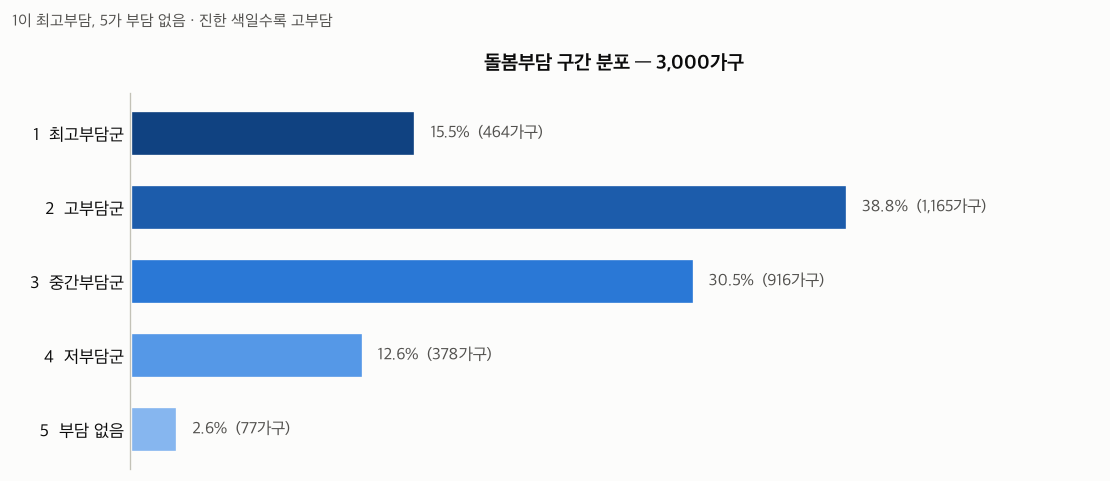

고부담군 이상(1~2단계, 즉시 안내 발동 임계값) = 54.3%
최고부담군(1단계, 상담 연계 강조)            = 15.5%
최소 구간(5단계) 대 최대 구간(2단계) 비율     = 1 : 15.1


부담 구간,최고부담군,고부담군,중간부담군,저부담군,부담 없음
split,,,,,
train,371,932,732,302,61
test,93,233,184,76,16


In [6]:
cnt = (df.groupby(["split", "care_burden"]).size().unstack("care_burden")
         .reindex(index=["train", "test"], columns=[1, 2, 3, 4, 5], fill_value=0))
pct_all = df["care_burden"].value_counts(normalize=True).reindex([1, 2, 3, 4, 5]) * 100
n_all   = df["care_burden"].value_counts().reindex([1, 2, 3, 4, 5])

fig, ax = plt.subplots(figsize=(9.2, 4.2))
ys = np.arange(5)[::-1]
bars = ax.barh(ys, pct_all.values, height=0.62, color=BURDEN_RAMP, edgecolor=SURFACE, linewidth=2)
for y, p, n in zip(ys, pct_all.values, n_all.values):
    ax.text(p + 0.8, y, f"{p:.1f}%  ({n:,}가구)", va="center", ha="left",
            fontsize=10, color=INK["secondary"])
ax.set_yticks(ys, [f"{i}  {BURDEN_NAME[i]}" for i in [1, 2, 3, 4, 5]], fontsize=10.5, color=INK["primary"])
ax.set_xlim(0, max(pct_all) * 1.35)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title("돌봄부담 구간 분포 — 3,000가구")
subtitle(fig, "1이 최고부담, 5가 부담 없음 · 진한 색일수록 고부담", y=0.905)
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

share_high = pct_all[[1, 2]].sum()
print(f"고부담군 이상(1~2단계, 즉시 안내 발동 임계값) = {share_high:.1f}%")
print(f"최고부담군(1단계, 상담 연계 강조)            = {pct_all[1]:.1f}%")
print(f"최소 구간(5단계) 대 최대 구간(2단계) 비율     = 1 : {pct_all.max()/pct_all.min():.1f}")
display(cnt.rename(columns=BURDEN_NAME).rename_axis(columns="부담 구간"))

## 차원 2 — 결측 구조

결측률이 높은 상위 변수는 **데이터 누락이 아니라 분기 문항의 "해당 없음"**이다.
예를 들어 `past_job_count`(과거 일자리 개수)의 88%는 과거 취업 경험이 없어 물을 수 없었던 응답이다.

이 구분이 중요한 이유는 두 가지다. 대치하면 정보를 훼손하고(원칙 I), 설문 UI에서 분기 대신
"해당사항 없음" 선택지로 구현해야 하기 때문이다(FR-004d).

아래 두 번째 그래프는 **결측 자체가 target과 상관되는지**를 확인한다. 결측 여부로 고부담군 비율이 갈리면
결측은 정보를 가진 신호이며, 지워서는 안 된다.

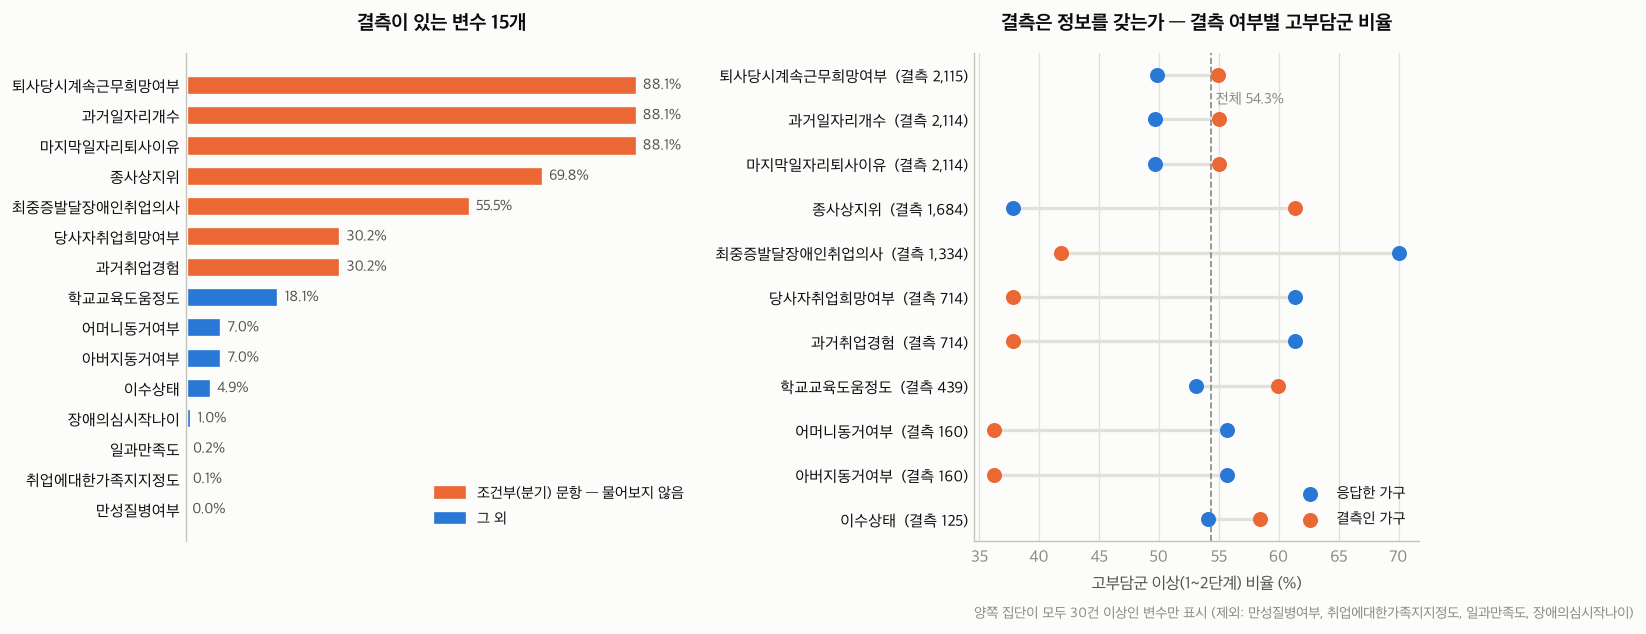

상태,결측,응답,차이
feature,,,
최중증발달장애인취업의사,41.8,70.0,-28.2
과거취업경험,37.8,61.3,-23.5
당사자취업희망여부,37.8,61.3,-23.5
종사상지위,61.3,37.8,23.5
아버지동거여부,36.2,55.6,-19.4
어머니동거여부,36.2,55.6,-19.4
학교교육도움정도,59.9,53.1,6.8
마지막일자리퇴사이유,55.0,49.6,5.3
과거일자리개수,55.0,49.6,5.3


In [7]:
miss = meta.loc[meta["missing_pct"] > 0, ["missing_pct", "scale_note"]].sort_values("missing_pct")
BRANCH = {"past_job_count", "last_job_quit_reason", "wanted_to_stay_at_last_job",
          "employment_status", "severe_dd_job_willingness", "past_employment_exp",
          "wants_person_employed"}     # 선행 문항 응답에 따라 물어보지 않은 조건부 문항

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})

# (1) 결측률
ax = axes[0]
ys = np.arange(len(miss))
colors = [CAT[1] if f in BRANCH else CAT[0] for f in miss.index]
ax.barh(ys, miss["missing_pct"], height=0.66, color=colors, edgecolor=SURFACE, linewidth=2)
for y, v in zip(ys, miss["missing_pct"]):
    ax.text(v + 1.2, y, f"{v:.1f}%", va="center", fontsize=9, color=INK["secondary"])
ax.set_yticks(ys, [lab(f) for f in miss.index], fontsize=9.5, color=INK["primary"])
ax.set_xlim(0, 100); ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title(f"결측이 있는 변수 {len(miss)}개")
handles = [plt.Rectangle((0, 0), 1, 1, color=CAT[1]), plt.Rectangle((0, 0), 1, 1, color=CAT[0])]
ax.legend(handles, ["조건부(분기) 문항 — 물어보지 않음", "그 외"], loc="lower right", fontsize=9)

# (2) 결측 여부별 고부담군 비율 — 양쪽 집단이 모두 30건 이상인 변수만
MIN_N = 30
rows = []
for f in miss.index:
    for is_na, sub in TRAIN.groupby(TRAIN[f].isna()):
        rows.append((f, "결측" if is_na else "응답", (sub["care_burden"] <= 2).mean() * 100, len(sub)))
gap  = pd.DataFrame(rows, columns=["feature", "상태", "고부담비율", "n"])
piv  = gap.pivot(index="feature", columns="상태", values="고부담비율")
piv_n = gap.pivot(index="feature", columns="상태", values="n").fillna(0)
keep = [f for f in miss.index if f in piv.index and piv_n.loc[f].min() >= MIN_N]
dropped = [f for f in miss.index if f not in keep]
piv, piv_n = piv.reindex(keep), piv_n.reindex(keep)
base = (TRAIN["care_burden"] <= 2).mean() * 100

ax = axes[1]

ys = np.arange(len(piv))
ax.axvline(base, color=INK["muted"], linestyle="--", linewidth=1)
ax.text(base + 0.4, len(piv) - 1.55, f"전체 {base:.1f}%", color=INK["muted"], fontsize=9, va="center")
for y, (f, r) in zip(ys, piv.iterrows()):
    ax.plot([r["응답"], r["결측"]], [y, y], color=INK["grid"], linewidth=2, zorder=1)
ax.scatter(piv["응답"], ys, s=64, color=CAT[0], zorder=3, label="응답한 가구")
ax.scatter(piv["결측"], ys, s=64, color=CAT[1], zorder=3, label="결측인 가구")
ax.set_yticks(ys, [f"{lab(f)}  (결측 {int(piv_n.loc[f, '결측']):,})" for f in piv.index],
              fontsize=9.5, color=INK["primary"])
ax.set_xlabel("고부담군 이상(1~2단계) 비율 (%)")
style(ax, xgrid=True)
ax.set_title("결측은 정보를 갖는가 — 결측 여부별 고부담군 비율")
ax.legend(loc="lower right", fontsize=9)
ax.text(0, -0.13, f"양쪽 집단이 모두 {MIN_N}건 이상인 변수만 표시 (제외: "
                  f"{', '.join(lab(f) for f in dropped) or '없음'})",
        transform=ax.transAxes, fontsize=8.5, color=INK["muted"], va="top")

fig.tight_layout()
plt.show()

piv_out = piv.assign(차이=lambda d: (d["결측"] - d["응답"]).round(1)).round(1)
display(piv_out.rename(index=LABEL).sort_values("차이", key=abs, ascending=False))

## 차원 3 — 변수 유형 구성

38개 설명변수가 어떤 척도로 이루어져 있는지 본다. 척도는 곧 전처리 방식이다 —
순서형은 그대로 넣을 수 있고, 명목형은 인코딩이 필요하며, 연속형은 스케일링 대상이다.

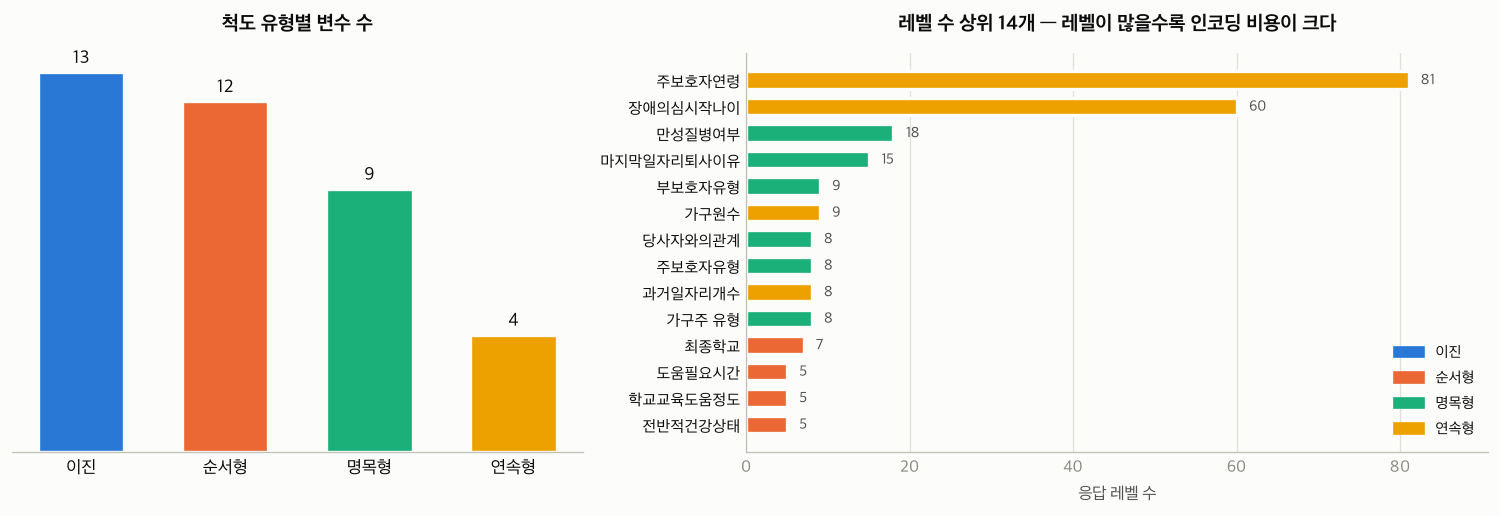

레벨 8개 이상 — one-hot 시 열이 급증하는 변수:


,유형,레벨 수,결측률(%)
feature,,,
주보호자연령,연속형,81,0.00
장애의심시작나이,연속형,60,1.00
만성질병여부,명목형,18,0.03
마지막일자리퇴사이유,명목형,15,88.10
가구원수,연속형,9,0.00
부보호자유형,명목형,9,0.00
가구주 유형,명목형,8,0.00
과거일자리개수,연속형,8,88.10
주보호자유형,명목형,8,0.00


In [8]:
scale_kr = {"ordinal": "순서형", "nominal": "명목형", "binary": "이진", "continuous": "연속형"}
m = meta.assign(유형=meta["var_scale"].map(scale_kr))

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4), gridspec_kw={"width_ratios": [1, 1.3]})

# (1) 유형별 변수 수
ax = axes[0]
vc = m["유형"].value_counts()
xs = np.arange(len(vc))
ax.bar(xs, vc.values, width=0.6, color=CAT[:len(vc)], edgecolor=SURFACE, linewidth=2)
for x, v in zip(xs, vc.values):
    ax.text(x, v + 0.3, str(v), ha="center", fontsize=11, color=INK["primary"])
ax.set_xticks(xs, vc.index, fontsize=10.5, color=INK["primary"])
ax.set_yticks([]); ax.spines["left"].set_visible(False)
style(ax)
ax.set_title("척도 유형별 변수 수")

# (2) 레벨 수 상위 — 인코딩 비용의 예고편
ax = axes[1]
cmap  = {k: CAT[i] for i, k in enumerate(vc.index)}
order = m.sort_values("n_levels", ascending=False).head(14)[::-1]
ys = np.arange(len(order))
ax.barh(ys, order["n_levels"], height=0.66, color=[cmap[t] for t in order["유형"]],
        edgecolor=SURFACE, linewidth=2)
for y, v in zip(ys, order["n_levels"]):
    ax.text(v + 1.5, y, str(int(v)), va="center", fontsize=9, color=INK["secondary"])
ax.set_yticks(ys, [lab(f) for f in order.index], fontsize=9.5, color=INK["primary"])
ax.set_xlabel("응답 레벨 수")
ax.set_xlim(0, order["n_levels"].max() * 1.12)
style(ax, xgrid=True)
ax.set_title("레벨 수 상위 14개 — 레벨이 많을수록 인코딩 비용이 크다")
big = m[m["n_levels"] >= 8].sort_values("n_levels", ascending=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[k]) for k in vc.index]
ax.legend(handles, list(vc.index), loc="lower right", fontsize=9)

fig.tight_layout()
plt.show()

print("레벨 8개 이상 — one-hot 시 열이 급증하는 변수:")
display(big[["유형", "n_levels", "missing_pct"]].rename(index=LABEL)
           .rename(columns={"n_levels": "레벨 수", "missing_pct": "결측률(%)"}))

## 차원 4 — 단독 설명력 (상호정보량 비율)

`MI/H`는 **변수 하나가 target 불확실성의 몇 %를 없애는지**를 뜻한다.
`train` 2,398건만으로 계산하며 `test`는 건드리지 않는다(원칙 IV, 노트북 마지막의 사용 제한 참조).

두 가지 처리를 한다.

- **결측을 버리지 않고 "해당없음" 범주로 넣는다.** 이 데이터의 결측 대부분은 분기 문항에서
  물어보지 않은 응답(차원 2)이라 그 자체가 정보다. 완전사례만 쓰면 결측률 88%인
  `마지막일자리퇴사이유`가 357건만으로 계산되어 설명력 5.9%로 4위에 오르는데, 이는 허수다
  (해당없음을 넣으면 0.76%).
- **연속형은 10분위로 묶는다.** 레벨이 81개인 `caregiver_age`를 원값으로 계산하면 값이 부풀려진다.
  문서의 표는 원값 기준이라 `caregiver_age`·`age_disability_suspected`만 여기서 더 낮게 나온다 — 정상이다.
  나머지 범주형 변수는 문서 표와 소수점까지 일치한다.

**이 순위를 문항 선별 기준으로 쓰면 안 된다.** 상호정보량은 변수를 하나씩만 보는 지표라
조합 효과와 중복을 반영하지 못한다. 최종 문항 집합은 38개 전체 모델 대비 성능 손실로 도출한다(FR-004c).

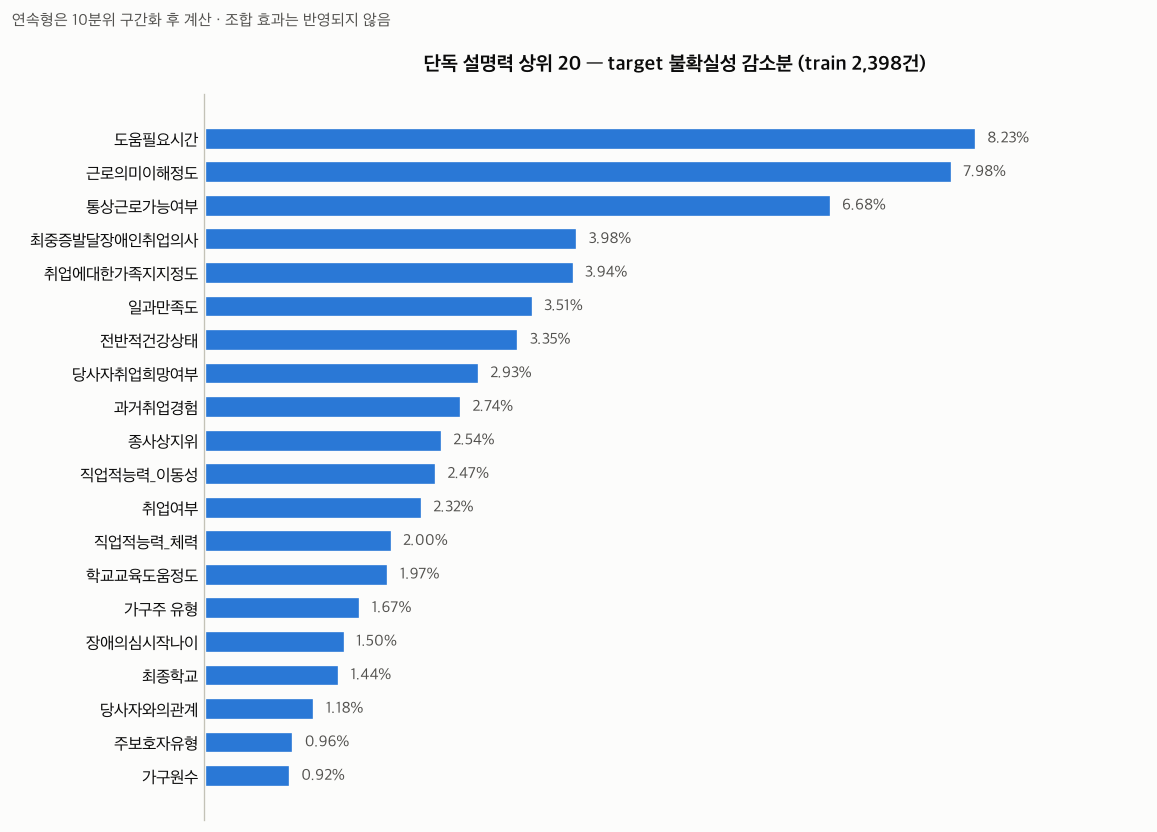

설명력 구간별 변수 수
5% 이상     3
2~5%     10
1~2%      5
1% 미만    20

하위 20개 변수의 단독 설명력 합계 = 9.51%


In [9]:
def mi_ratio(x, y, bins=10):
    """MI(x;y) / H(y).
    결측은 버리지 않고 '결측/해당없음'이라는 하나의 범주로 넣는다 — 이 데이터의 결측 대부분은
    분기 문항의 '해당 없음'이라는 실제 정보이고, 완전사례만 쓰면 결측률 88% 변수가
    357건만으로 계산되어 설명력이 부풀려진다.
    연속형(레벨 12 초과)은 분위 구간으로 이산화한다."""
    xb = (pd.qcut(x, q=min(bins, x.nunique()), duplicates="drop").astype(object)
          if x.nunique() > 12 else x.astype(object))
    xb = xb.where(x.notna(), "결측/해당없음")
    ct = pd.crosstab(xb, y).to_numpy(float)
    if ct.size == 0 or ct.sum() == 0:
        return np.nan
    p   = ct / ct.sum()
    px  = p.sum(1, keepdims=True)
    py  = p.sum(0, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = np.where(p > 0, p * np.log(p / (px * py)), 0.0)
    hy = -np.sum(py[py > 0] * np.log(py[py > 0]))
    return float(t.sum() / hy) * 100


mi = (pd.Series({f: mi_ratio(TRAIN[f], TRAIN["care_burden"]) for f in FEATURES})
        .sort_values(ascending=False))

top = mi.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9.6, 7.2))
ys = np.arange(len(top))
ax.barh(ys, top.values, height=0.68, color=CAT[0], edgecolor=SURFACE, linewidth=2)
for y, v in zip(ys, top.values):
    ax.text(v + 0.12, y, f"{v:.2f}%", va="center", fontsize=9.5, color=INK["secondary"])
ax.set_yticks(ys, [lab(f) for f in top.index], fontsize=10, color=INK["primary"])
ax.set_xlim(0, top.max() * 1.22); ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title("단독 설명력 상위 20 — target 불확실성 감소분 (train 2,398건)")
subtitle(fig, "연속형은 10분위 구간화 후 계산 · 조합 효과는 반영되지 않음", y=0.935)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

band = pd.cut(mi, [-0.01, 1, 2, 5, 100], labels=["1% 미만", "1~2%", "2~5%", "5% 이상"])
print("설명력 구간별 변수 수")
print(band.value_counts().reindex(["5% 이상", "2~5%", "1~2%", "1% 미만"]).to_string())
print(f"\n하위 {int((mi < 1).sum())}개 변수의 단독 설명력 합계 = {mi[mi < 1].sum():.2f}%")

### 배제 비용 — 뺀 6개는 얼마나 강력했나

차원 0.5에서 제거한 6개의 설명력을 **원천 테이블에서 직접 계산해** 잔존 변수와 나란히 놓는다.
배제가 공짜가 아니었음을 눈으로 확인하기 위한 것이다.

원천 테이블에는 `split` 정보가 없어 이 계산만 3,000건 전체를 쓴다. 결측 처리는 위와 같다
(`work_care_gap_hours`는 응답이 2%뿐이라 대부분이 "해당없음" 범주로 들어가고, 그만큼 설명력도 낮게 나온다).

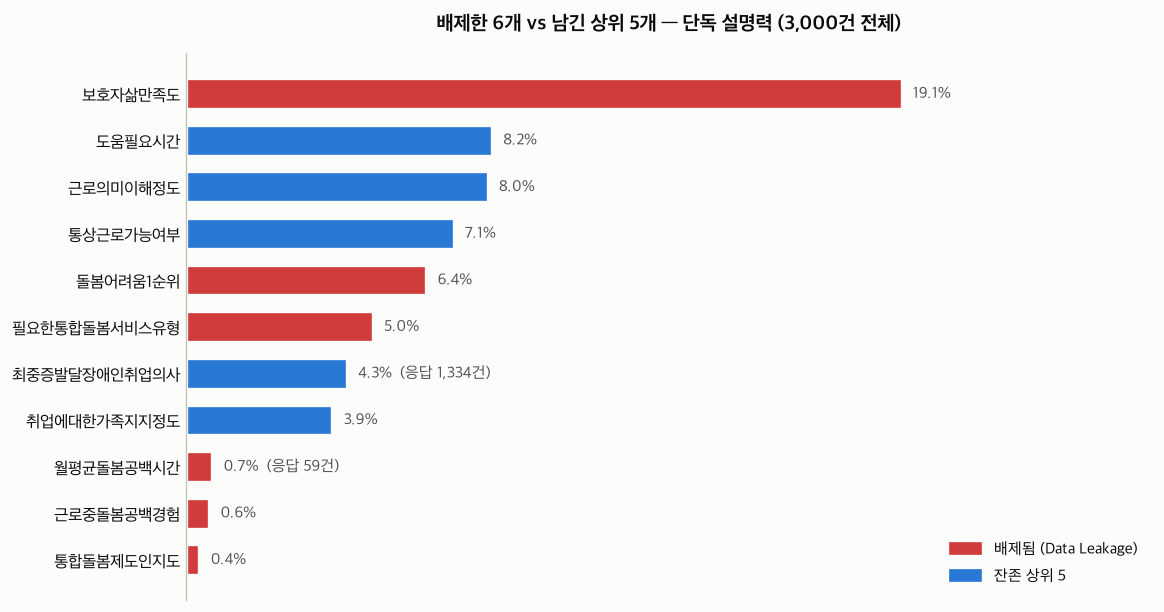

배제된 변수 중 최대 설명력 = 19.06%  (보호자삶만족도)
잔존 변수 중 최대 설명력   = 8.15%  (도움필요시간)
→ 설명력 1위 변수를 통째로 잃었고, 그 격차는 10.91%p다.

그럼에도 배제한 이유: 이 변수들을 쓰면 모델 성능은 오르지만 진단 도구로서는 무의미해진다.


In [10]:
lk = query("SELECT care_burden, " + ", ".join(f"`{c}`" for c in LK_COLS)
           + " FROM `2024_care_burden_std09`")
for c in LK_COLS:                       # 원천은 TEXT 컬럼이 섞여 있다 — 공백을 결측으로 정규화
    if lk[c].dtype == object:
        lk[c] = pd.to_numeric(lk[c].astype(str).str.strip().replace({"": None}), errors="coerce")

lk_mi = pd.Series({c: mi_ratio(lk[c], lk["care_burden"]) for c in LK_COLS})
lk_n  = lk[LK_COLS].notna().sum()

keep_mi = pd.Series({f: mi_ratio(df[f], df["care_burden"]) for f in mi.head(5).index})  # 잔존 상위 5 (전체 기준)
comp = pd.concat([
    pd.DataFrame({"mi": lk_mi,   "n": lk_n,                          "구분": "배제됨 (Data Leakage)"}),
    pd.DataFrame({"mi": keep_mi, "n": df[list(keep_mi.index)].notna().sum(), "구분": "잔존 상위 5"}),
]).sort_values("mi")

fig, ax = plt.subplots(figsize=(9.8, 5.2))
ys = np.arange(len(comp))
colors = [CRITICAL if g.startswith("배제") else CAT[0] for g in comp["구분"]]
ax.barh(ys, comp["mi"], height=0.66, color=colors, edgecolor=SURFACE, linewidth=2)
for y, (f, r) in zip(ys, comp.iterrows()):
    tail = f"  (응답 {int(r['n']):,}건)" if r["n"] < len(lk) * 0.5 else ""
    ax.text(r["mi"] + 0.3, y, f"{r['mi']:.1f}%{tail}", va="center", fontsize=9.5, color=INK["secondary"])
ax.set_yticks(ys, [LK_LABEL.get(f, lab(f)) for f in comp.index], fontsize=10, color=INK["primary"])
ax.set_xlim(0, comp["mi"].max() * 1.35); ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title("배제한 6개 vs 남긴 상위 5개 — 단독 설명력 (3,000건 전체)")
h = [plt.Rectangle((0, 0), 1, 1, color=CRITICAL), plt.Rectangle((0, 0), 1, 1, color=CAT[0])]
ax.legend(h, ["배제됨 (Data Leakage)", "잔존 상위 5"], loc="lower right", fontsize=9.5)
fig.tight_layout()
plt.show()

top_excluded, top_kept = lk_mi.max(), keep_mi.max()
print(f"배제된 변수 중 최대 설명력 = {top_excluded:.2f}%  ({LK_LABEL[lk_mi.idxmax()]})")
print(f"잔존 변수 중 최대 설명력   = {top_kept:.2f}%  ({lab(keep_mi.idxmax())})")
print(f"→ 설명력 1위 변수를 통째로 잃었고, 그 격차는 {top_excluded - top_kept:.2f}%p다.")
print("\n그럼에도 배제한 이유: 이 변수들을 쓰면 모델 성능은 오르지만 진단 도구로서는 무의미해진다.")

## 차원 5 — 순서형 변수 × 부담 구간

설명력 상위 순서형 변수 넷을 골라, **응답 수준이 오를수록 부담 분포가 단조롭게 움직이는지** 본다.
100% 누적 막대이므로 각 행의 길이는 같고, 진한 색(고부담)이 차지하는 왼쪽 면적만 비교하면 된다.

단조성이 확인되면 그 변수는 순서형 그대로 모델에 넣을 수 있고, SHAP 설명 문장으로 옮기기도 쉽다(FR-011).

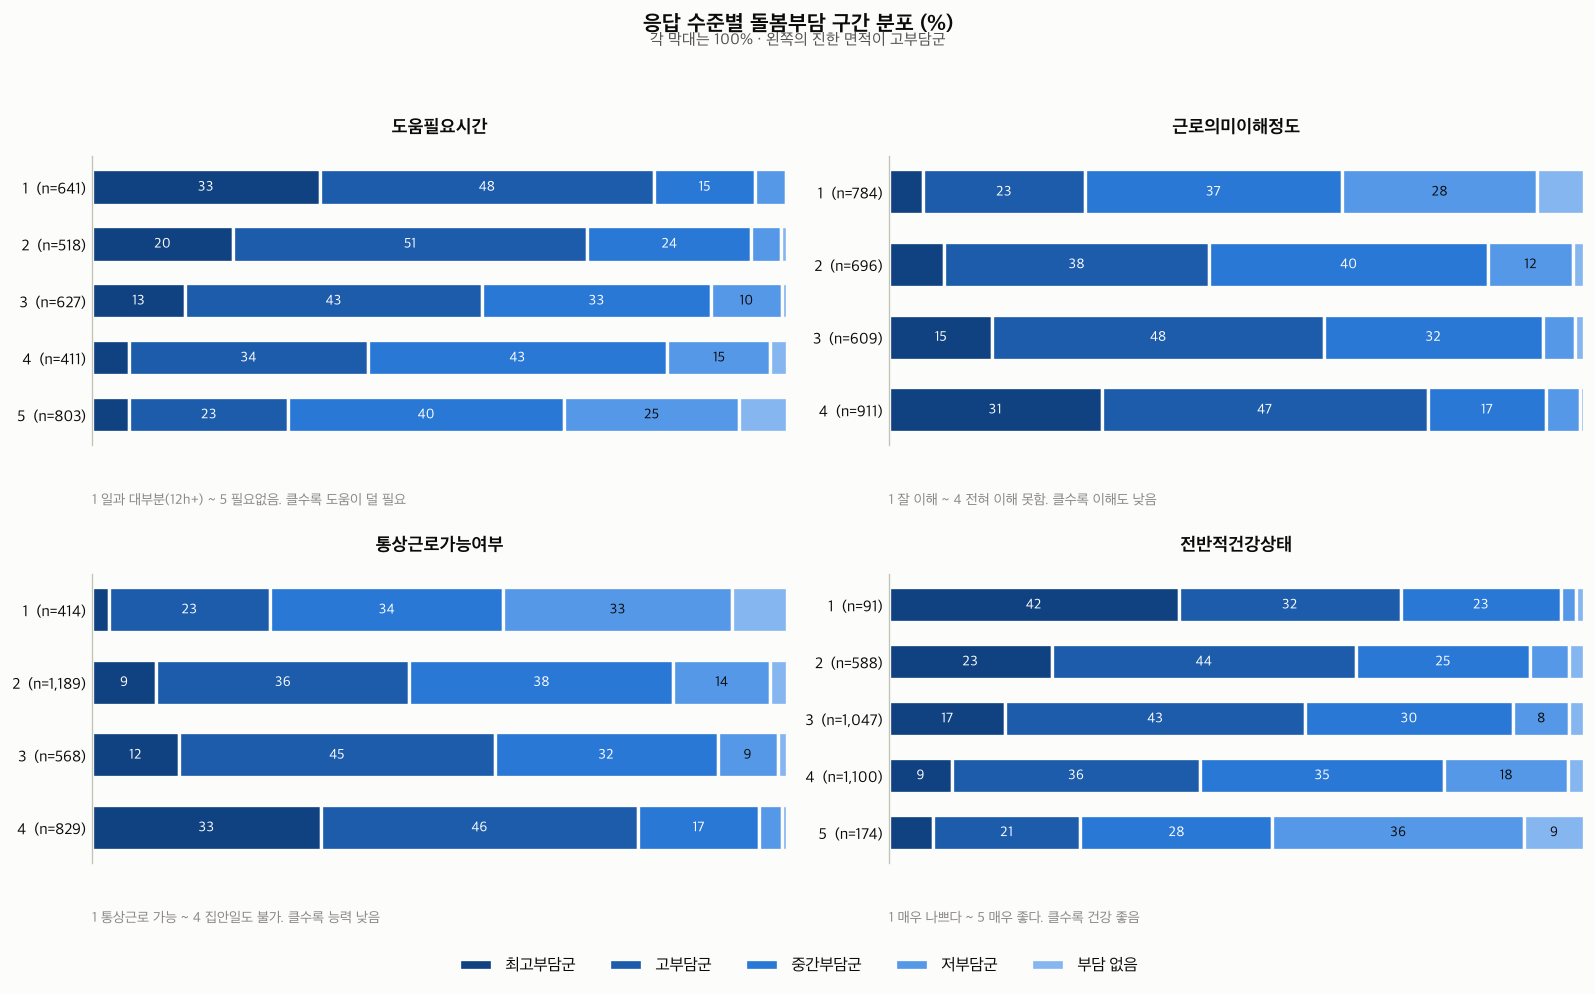

응답 수준별 고부담군(1~2단계) 비율 (%)


,도움필요시간,근로의미이해정도,통상근로가능여부,전반적건강상태
응답 수준,,,,
1,80.8,28.2,25.6,73.6
2,71.2,46.1,45.7,67.2
3,56.1,62.6,57.9,59.9
4,39.7,77.5,78.5,44.7
5,28.3,NaN,NaN,27.6


In [11]:
def stacked_by_burden(ax, col, data, value_labels=None, min_n=1):
    """col의 각 응답 수준별 부담 구간 분포를 100% 누적 가로 막대로."""
    sub = data[data[col].notna()]
    ct  = pd.crosstab(sub[col], sub["care_burden"]).reindex(columns=[1, 2, 3, 4, 5], fill_value=0)
    n   = ct.sum(1)
    ct  = ct[n >= min_n]; n = n[n >= min_n]
    pct = ct.div(ct.sum(1), axis=0) * 100

    ys, left = np.arange(len(pct))[::-1], np.zeros(len(pct))
    for i, lv in enumerate([1, 2, 3, 4, 5]):
        v = pct[lv].to_numpy()
        ax.barh(ys, v, left=left, height=0.62, color=BURDEN_RAMP[i],
                edgecolor=SURFACE, linewidth=2, label=BURDEN_NAME[lv])
        for y, val, l in zip(ys, v, left):
            if val >= 8:
                ax.text(l + val / 2, y, f"{val:.0f}", ha="center", va="center", fontsize=8.5,
                        color="#ffffff" if i < 3 else INK["primary"])
        left += v

    if value_labels:
        ticks = [f"{value_labels.get(int(k), k)}  (n={n[k]:,})" for k in pct.index]
    else:
        ticks = [f"{int(k)}  (n={n[k]:,})" for k in pct.index]
    ax.set_yticks(ys, ticks, fontsize=9.5, color=INK["primary"])
    ax.set_xlim(0, 100); ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)
    style(ax)
    return pct


ORDINALS = ["help_needed_hours", "understands_work_meaning", "can_work_standard_job", "overall_health"]

fig, axes = plt.subplots(2, 2, figsize=(13.4, 8.0))
for ax, col in zip(axes.ravel(), ORDINALS):
    stacked_by_burden(ax, col, df)
    ax.set_title(lab(col), fontsize=11)
    ax.text(0, -0.16, note(col), transform=ax.transAxes, fontsize=8.5, color=INK["muted"], va="top")

h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("응답 수준별 돌봄부담 구간 분포 (%)", fontsize=13, fontweight="bold", y=1.0)
fig.text(0.5, 0.965, "각 막대는 100% · 왼쪽의 진한 면적이 고부담군", ha="center",
         fontsize=9.5, color=INK["secondary"])
fig.tight_layout(rect=[0, 0.02, 1, 0.955])
plt.show()

print("응답 수준별 고부담군(1~2단계) 비율 (%)")
tbl = pd.DataFrame({lab(c): (df[df[c].notna()].groupby(c)["care_burden"]
                             .apply(lambda s: (s <= 2).mean() * 100).round(1))
                    for c in ORDINALS})
display(tbl.rename_axis("응답 수준"))

## 차원 6 — 연속형 변수 × 부담 구간

연속형은 셋뿐이다(`caregiver_age`, `age_disability_suspected`, `household_size`, `past_job_count`).
이 중 결측이 없고 해석이 분명한 앞의 셋을 본다.

`age_disability_suspected`(장애를 처음 의심한 나이)는 **당사자의 현재 연령이 데이터에 없는 상황에서
생애주기를 가늠하는 유일한 단서**다. 조기 발현일수록 중증도가 높고 돌봄 기간이 길어진다는 가설을 확인한다.

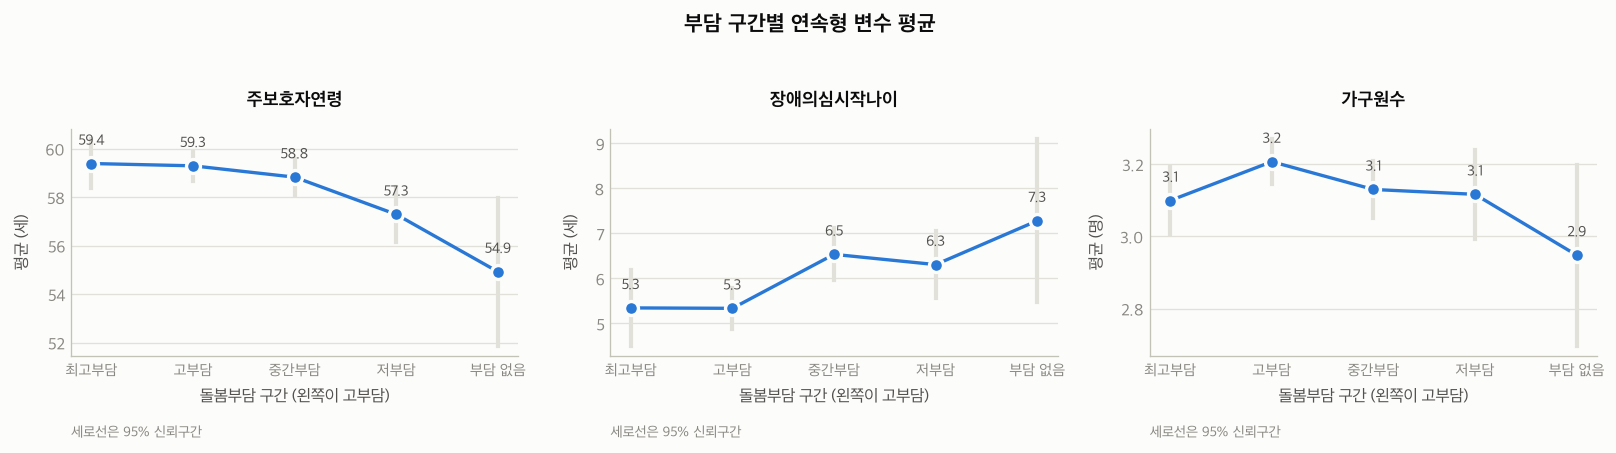

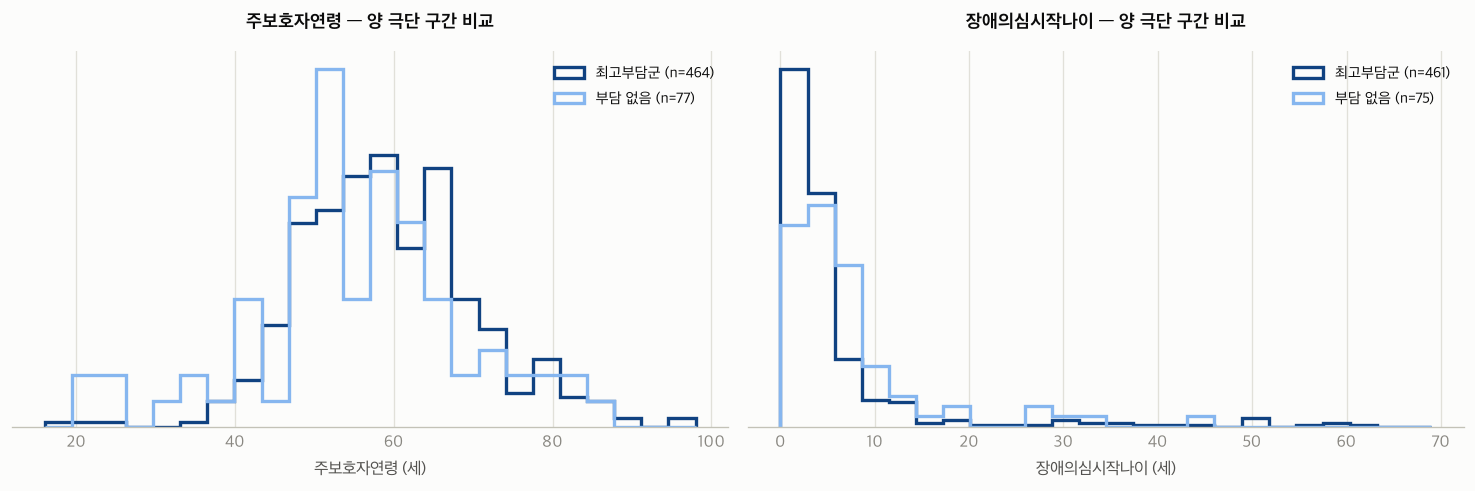

,주보호자연령,장애의심시작나이,가구원수
부담 구간,,,
최고부담군,59.39,5.34,3.10
고부담군,59.29,5.34,3.21
중간부담군,58.82,6.53,3.13
저부담군,57.29,6.31,3.12
부담 없음,54.92,7.28,2.95


In [12]:
CONTINUOUS = ["caregiver_age", "age_disability_suspected", "household_size"]

fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.4))
for ax, col in zip(axes, CONTINUOUS):
    g = df.groupby("care_burden")[col]
    mean, se = g.mean(), g.std() / np.sqrt(g.count())
    xs = np.array([1, 2, 3, 4, 5])
    for x, m_, s_ in zip(xs, mean, se):
        ax.plot([x, x], [m_ - 1.96 * s_, m_ + 1.96 * s_], color=INK["grid"], linewidth=2.5, zorder=1)
    ax.plot(xs, mean.values, color=CAT[0], linewidth=2, zorder=2)
    ax.scatter(xs, mean.values, s=70, color=CAT[0], edgecolor=SURFACE, linewidth=2, zorder=3)
    for x, m_ in zip(xs, mean.values):
        ax.annotate(f"{m_:.1f}", (x, m_), textcoords="offset points", xytext=(0, 11),
                    ha="center", fontsize=9, color=INK["secondary"])
    ax.set_xticks(xs, [BURDEN_NAME[i].replace("군", "") for i in xs], fontsize=9)
    ax.set_xlabel("돌봄부담 구간 (왼쪽이 고부담)")
    ax.set_ylabel("평균 (명)" if col == "household_size" else "평균 (세)", labelpad=8)
    style(ax, ygrid=True)
    ax.set_title(lab(col), fontsize=11)
    ax.text(0, -0.30, "세로선은 95% 신뢰구간", transform=ax.transAxes,
            fontsize=8.5, color=INK["muted"], va="top")

fig.suptitle("부담 구간별 연속형 변수 평균", fontsize=13, fontweight="bold")
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 최고부담군과 부담없음 두 집단의 분포를 겹쳐 본다 — 평균 차이가 분포 이동인지 꼬리 효과인지 구분.
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
for ax, col in zip(axes, ["caregiver_age", "age_disability_suspected"]):
    bins = np.histogram_bin_edges(df[col].dropna(), bins=24)
    for i, (lv, color) in enumerate([(1, BURDEN_RAMP[0]), (5, BURDEN_RAMP[4])]):
        v = df.loc[df["care_burden"] == lv, col].dropna()
        ax.hist(v, bins=bins, density=True, histtype="step", linewidth=2,
                color=color, label=f"{BURDEN_NAME[lv]} (n={len(v):,})")
    ax.set_xlabel(f"{lab(col)} (세)"); ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    style(ax, xgrid=True)
    ax.set_title(f"{lab(col)} — 양 극단 구간 비교", fontsize=11)
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

display(df.groupby("care_burden")[CONTINUOUS].mean().round(2)
          .rename(index=BURDEN_NAME).rename(columns=LABEL).rename_axis("부담 구간"))

## 차원 7 — 가구주 유형별 부담

`household_head_type`은 이름과 달리 이진 플래그가 아니라 **가구주가 누구인지를 나타내는 8개 범주**다.
(원천 컬럼명은 `is_household_head`였으나 오독을 막으려고 `cb_dataset_v1`에서 개명했다.)

단독 설명력은 중위권이지만 **범주마다 해석이 명확해 SHAP 설명 문장으로 옮기기 좋은 변수**다.
표본이 작은 범주(n<50)는 회색 처리해 과잉 해석을 막는다.

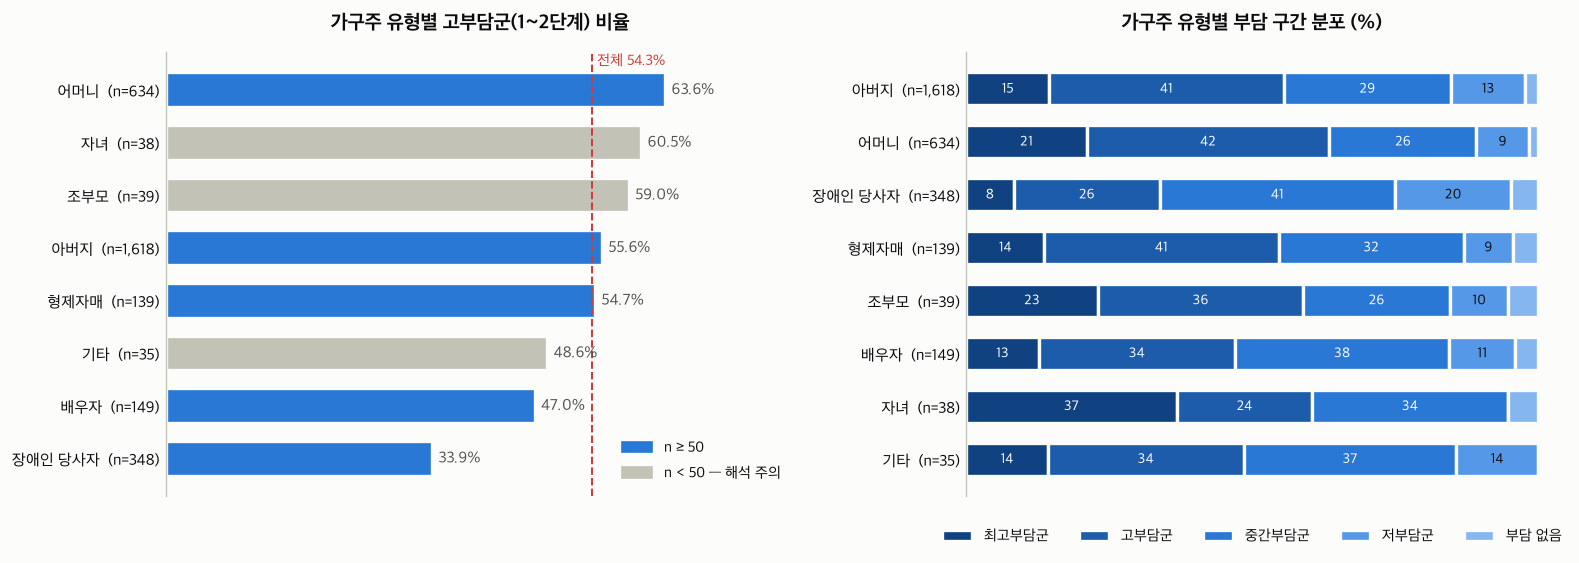

,n,평균부담,고부담비율(%),당사자 취업률(%)
가구주,,,,
장애인 당사자,348,2.87,33.91,29.31
배우자,149,2.60,46.98,13.42
기타,35,2.51,48.57,14.29
형제자매,139,2.49,54.68,19.42
아버지,1618,2.47,55.56,33.99
조부모,39,2.38,58.97,30.77
자녀,38,2.13,60.53,2.63
어머니,634,2.28,63.56,29.81


In [13]:
col = "household_head_type"
g = df.groupby(col)["care_burden"]
summ = pd.DataFrame({"n": g.size(), "평균부담": g.mean(),
                     "고부담비율": g.apply(lambda s: (s <= 2).mean() * 100)})
summ["취업률"] = df.groupby(col)["is_employed"].apply(lambda s: (s == 1).mean() * 100)
summ = summ.sort_values("고부담비율")
base = (df["care_burden"] <= 2).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
ys = np.arange(len(summ))
colors = [CAT[0] if n >= 50 else INK["axis"] for n in summ["n"]]
ax.barh(ys, summ["고부담비율"], height=0.66, color=colors, edgecolor=SURFACE, linewidth=2)
ax.axvline(base, color=CRITICAL, linestyle="--", linewidth=1.2, zorder=3)
ax.text(base + 0.6, len(summ) - 0.45, f"전체 {base:.1f}%", color=CRITICAL, fontsize=9, va="center")
for y, (k, r) in zip(ys, summ.iterrows()):
    ax.text(r["고부담비율"] + 0.8, y, f"{r['고부담비율']:.1f}%", va="center",
            fontsize=9.5, color=INK["secondary"])
ax.set_yticks(ys, [f"{VALUE_LABEL[col][int(k)]}  (n={int(r['n']):,})" for k, r in summ.iterrows()],
              fontsize=9.5, color=INK["primary"])
ax.set_xlim(0, 80); ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title("가구주 유형별 고부담군(1~2단계) 비율")
h = [plt.Rectangle((0, 0), 1, 1, color=CAT[0]), plt.Rectangle((0, 0), 1, 1, color=INK["axis"])]
ax.legend(h, ["n ≥ 50", "n < 50 — 해석 주의"], loc="lower right", fontsize=9)

ax = axes[1]
stacked_by_burden(ax, col, df, value_labels=VALUE_LABEL[col])
ax.set_title("가구주 유형별 부담 구간 분포 (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.04), ncol=5, fontsize=9)

fig.tight_layout()
plt.show()

display(summ.round(2).rename(index=VALUE_LABEL[col]).rename_axis("가구주")
            .rename(columns={"고부담비율": "고부담비율(%)", "취업률": "당사자 취업률(%)"}))

## 차원 8 — 보조 돌봄제공자 역설

`secondary_caregiver_type = 9`는 결측이 아니라 **"보조 돌봄제공자 없음"이라는 실제 범주**다.
"돌봄을 나눌 사람이 없으면 부담이 크다"는 통념이 데이터에서 성립하는지 직접 확인한다.

결과가 통념과 어긋난다면 **역인과**로 읽는 것이 자연스럽다 — 부담이 큰 가구일수록 보조 돌봄제공자가
투입되는 것이지, 보조 제공자가 없어서 부담이 커지는 것이 아니다.
이 변수가 SHAP 상위 요인으로 올라올 때 인과로 읽히는 문장이 만들어지지 않도록 주의해야 한다(FR-011).

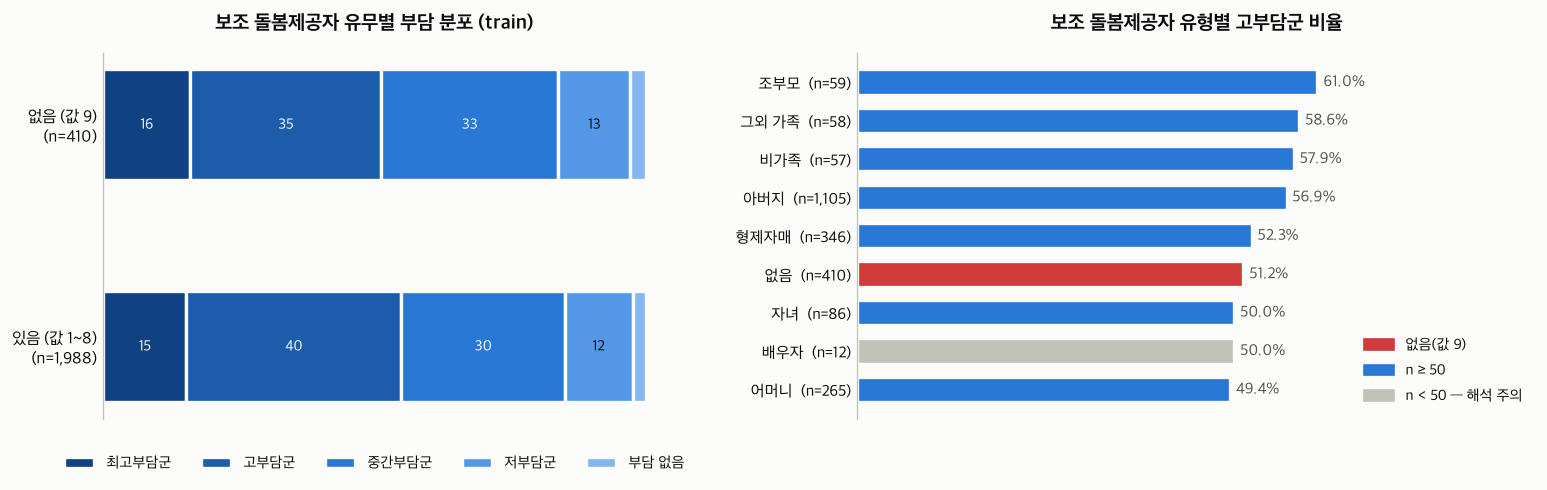

,n,평균부담,고부담비율
보조 돌봄제공자,,,
없음 (값 9),410,2.517,51.22
있음 (값 1~8),1988,2.471,54.98


고부담군 비율 차이(없음 - 있음) = -3.8%p  →  통념과 반대


In [14]:
col = "secondary_caregiver_type"
tr  = TRAIN.copy()
tr["보조 돌봄제공자"] = np.where(tr[col] == 9, "없음 (값 9)", "있음 (값 1~8)")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2), gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
ct  = pd.crosstab(tr["보조 돌봄제공자"], tr["care_burden"]).reindex(
        index=["없음 (값 9)", "있음 (값 1~8)"], columns=[1, 2, 3, 4, 5], fill_value=0)
pct = ct.div(ct.sum(1), axis=0) * 100
ys, left = np.arange(len(pct))[::-1], np.zeros(len(pct))
for i, lv in enumerate([1, 2, 3, 4, 5]):
    v = pct[lv].to_numpy()
    ax.barh(ys, v, left=left, height=0.5, color=BURDEN_RAMP[i], edgecolor=SURFACE,
            linewidth=2, label=BURDEN_NAME[lv])
    for y, val, l in zip(ys, v, left):
        if val >= 8:
            ax.text(l + val / 2, y, f"{val:.0f}", ha="center", va="center", fontsize=9,
                    color="#ffffff" if i < 3 else INK["primary"])
    left += v
ax.set_yticks(ys, [f"{k}\n(n={ct.sum(1)[k]:,})" for k in pct.index], fontsize=10, color=INK["primary"])
ax.set_xlim(0, 100); ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title("보조 돌봄제공자 유무별 부담 분포 (train)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=5, fontsize=9)

ax = axes[1]
sub = TRAIN[TRAIN[col].notna()]
by  = pd.DataFrame({"n": sub.groupby(col).size(),
                    "고부담비율": sub.groupby(col)["care_burden"].apply(lambda s: (s <= 2).mean() * 100)})
by  = by.sort_values("고부담비율")
ys  = np.arange(len(by))
colors = [CRITICAL if int(k) == 9 else (CAT[0] if n >= 50 else INK["axis"])
          for k, n in zip(by.index, by["n"])]
ax.barh(ys, by["고부담비율"], height=0.66, color=colors, edgecolor=SURFACE, linewidth=2)
for y, (k, r) in zip(ys, by.iterrows()):
    ax.text(r["고부담비율"] + 0.8, y, f"{r['고부담비율']:.1f}%", va="center",
            fontsize=9.5, color=INK["secondary"])
ax.set_yticks(ys, [f"{VALUE_LABEL[col][int(k)]}  (n={int(r['n']):,})" for k, r in by.iterrows()],
              fontsize=9.5, color=INK["primary"])
ax.set_xlim(0, 90); ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
style(ax)
ax.set_title("보조 돌봄제공자 유형별 고부담군 비율")
h = [plt.Rectangle((0, 0), 1, 1, color=CRITICAL), plt.Rectangle((0, 0), 1, 1, color=CAT[0]),
     plt.Rectangle((0, 0), 1, 1, color=INK["axis"])]
ax.legend(h, ["없음(값 9)", "n ≥ 50", "n < 50 — 해석 주의"], loc="lower right", fontsize=9)

fig.tight_layout()
plt.show()

comp = tr.groupby("보조 돌봄제공자").agg(n=("care_burden", "size"),
                                    평균부담=("care_burden", "mean"),
                                    고부담비율=("care_burden", lambda s: (s <= 2).mean() * 100)).round(3)
display(comp)
d = comp.loc["없음 (값 9)", "고부담비율"] - comp.loc["있음 (값 1~8)", "고부담비율"]
print(f"고부담군 비율 차이(없음 - 있음) = {d:+.1f}%p"
      f"  →  {'통념과 반대' if d < 0 else '통념과 일치'}")

## 차원 9 — 변수 간 연관 구조

상호정보량 순위(차원 4)는 변수를 하나씩만 본다. 실제 문항 선별에서는 **변수끼리 겹치는지**가 관건이다.
두 변수가 거의 같은 것을 재고 있다면 둘 다 넣을 이유가 없다.

Cramér's V로 설명변수 간 연관 강도를 재고, 값이 큰 쌍을 뽑는다. 연속형은 5분위로 묶고,
결측은 차원 4와 같이 "해당없음" 범주로 넣는다.

그러면 **연관 강도가 정확히 1.00인 쌍**이 나타난다. 내용이 같아서가 아니라 **설문 분기 때문**이다 —
`취업여부`가 취업이면 과거 취업 이력을, 미취업이면 종사상지위를 묻지 않으므로 결측 패턴만으로
`취업여부`를 완벽히 복원할 수 있다. 아래 표는 이 둘을 구분해 표시한다.

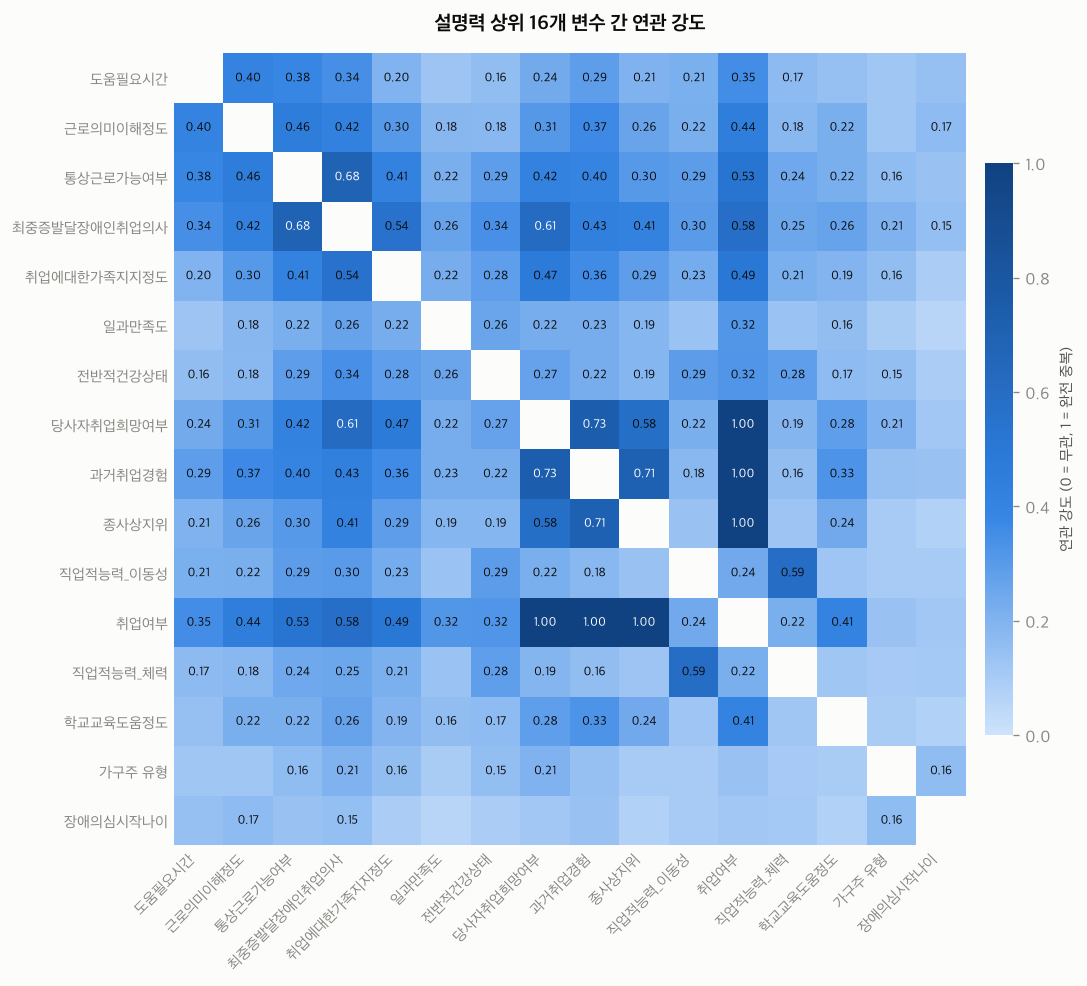

가장 강하게 겹치는 변수 쌍 — 문항 축소 시 한쪽만 남길 후보


변수 A,변수 B,연관 강도,성격
종사상지위,취업여부,1.000000,분기 구조 — 한쪽의 '해당없음'이 다른 쪽 값을 결정
과거취업경험,취업여부,1.000000,분기 구조 — 한쪽의 '해당없음'이 다른 쪽 값을 결정
당사자취업희망여부,취업여부,1.000000,분기 구조 — 한쪽의 '해당없음'이 다른 쪽 값을 결정
당사자취업희망여부,과거취업경험,0.733000,응답 내용 간 연관
과거취업경험,종사상지위,0.707000,응답 내용 간 연관
통상근로가능여부,최중증발달장애인취업의사,0.682000,응답 내용 간 연관
최중증발달장애인취업의사,당사자취업희망여부,0.607000,응답 내용 간 연관
직업적능력_이동성,직업적능력_체력,0.593000,응답 내용 간 연관
최중증발달장애인취업의사,취업여부,0.582000,응답 내용 간 연관
당사자취업희망여부,종사상지위,0.577000,응답 내용 간 연관



연관 강도 1.00인 쌍 3개는 내용이 같아서가 아니라 설문 분기 때문이다.
`취업여부`가 취업이면 과거 취업 이력 문항을, 미취업이면 종사상지위 문항을 묻지 않으므로,
결측 자체가 `취업여부`를 완벽히 알려준다. 문항을 줄일 때는 이 셋 중 하나가 아니라
`취업여부`를 축으로 남기고 나머지를 조건부로 두는 것이 자연스럽다.


In [15]:
def cramers_v(a, b, bins=5):
    """Cramér's V — 두 범주형 변수의 연관 강도 (0~1).
    결측 처리는 mi_ratio와 동일하게 '결측/해당없음' 범주로 넣는다."""
    if a.nunique() < 2 or b.nunique() < 2:
        return np.nan
    def prep(s):
        t = (pd.qcut(s, q=min(bins, s.nunique()), duplicates="drop").astype(object)
             if s.nunique() > 12 else s.astype(object))
        return t.where(s.notna(), "결측/해당없음")
    a, b = prep(a), prep(b)
    ct = pd.crosstab(a, b).to_numpy(float)
    n  = ct.sum()
    exp = ct.sum(1, keepdims=True) @ ct.sum(0, keepdims=True) / n
    chi2 = np.nansum(np.where(exp > 0, (ct - exp) ** 2 / exp, 0.0))
    r, k = ct.shape
    return float(np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1)))


PICK = list(mi.head(16).index)                       # 설명력 상위 16개만
V = pd.DataFrame(np.eye(len(PICK)), index=PICK, columns=PICK)
for i, a in enumerate(PICK):
    for b in PICK[i + 1:]:
        v = cramers_v(TRAIN[a], TRAIN[b])
        V.loc[a, b] = V.loc[b, a] = v

fig, ax = plt.subplots(figsize=(9.6, 8.2))
M = V.to_numpy(float).copy()
np.fill_diagonal(M, np.nan)                          # 대각선은 정보가 없다
im = ax.imshow(M, cmap=SEQ_CMAP, vmin=0, vmax=np.nanmax(M))
ax.set_xticks(range(len(PICK)), [lab(f) for f in PICK], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(PICK)), [lab(f) for f in PICK], fontsize=9)
for i in range(len(PICK)):
    for j in range(len(PICK)):
        if i != j and not np.isnan(M[i, j]) and M[i, j] >= 0.15:
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="#ffffff" if M[i, j] > np.nanmax(M) * 0.6 else INK["primary"])
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
cb.set_label("연관 강도 (0 = 무관, 1 = 완전 중복)", fontsize=9, color=INK["secondary"])
cb.outline.set_visible(False)
ax.set_title("설명력 상위 16개 변수 간 연관 강도")
fig.tight_layout()
plt.show()

pairs = (V.where(np.triu(np.ones(V.shape), 1).astype(bool)).stack()
          .sort_values(ascending=False).head(14).rename("V").reset_index())
pairs.columns = ["A", "B", "V"]
pairs["성격"] = np.where(pairs["V"] >= 0.99,
                       "분기 구조 — 한쪽의 '해당없음'이 다른 쪽 값을 결정",
                       "응답 내용 간 연관")
pairs["변수 A"] = pairs["A"].map(lab); pairs["변수 B"] = pairs["B"].map(lab)
out = pairs[["변수 A", "변수 B", "V", "성격"]].rename(columns={"V": "연관 강도"}).round(3)

print("가장 강하게 겹치는 변수 쌍 — 문항 축소 시 한쪽만 남길 후보")
display(out.style.hide(axis="index"))

n_branch = int((pairs["V"] >= 0.99).sum())
print(f"\n연관 강도 1.00인 쌍 {n_branch}개는 내용이 같아서가 아니라 설문 분기 때문이다.")
print("`취업여부`가 취업이면 과거 취업 이력 문항을, 미취업이면 종사상지위 문항을 묻지 않으므로,")
print("결측 자체가 `취업여부`를 완벽히 알려준다. 문항을 줄일 때는 이 셋 중 하나가 아니라")
print("`취업여부`를 축으로 남기고 나머지를 조건부로 두는 것이 자연스럽다.")

## 차원 10 — 분할 무결성

`split`(train/test)과 `cv_fold`(1~5)는 문서화된 층화 분할이다. 이것이 실제로 층화되어 있어야
문항 선별·판정 불가 기준 보정·하이퍼파라미터 튜닝·모델 선택을 **같은 분할 위에서** 비교할 수 있다(FR-012).

두 가지를 확인한다 — ① train과 test의 부담 구간 비율이 같은가, ② 5개 fold 사이에 편차가 없는가.

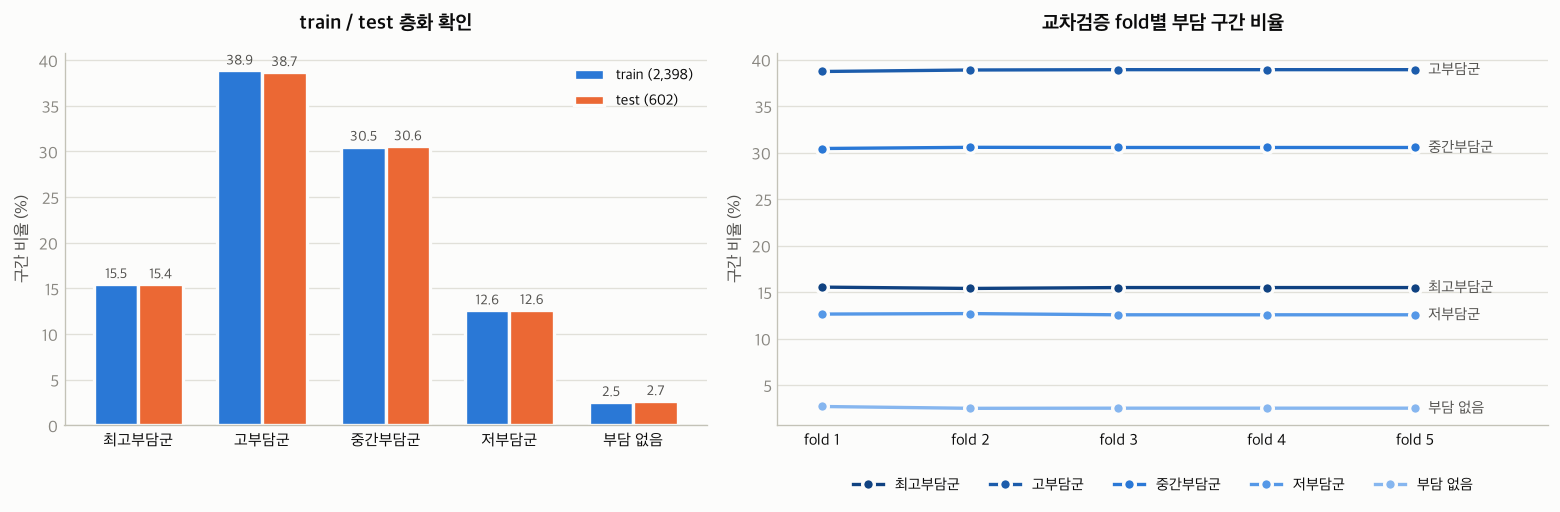

fold 간 최대-최소 비율 차이 (%p)
care_burden
최고부담군    0.14
고부담군     0.20
중간부담군    0.13
저부담군     0.13
부담 없음    0.20

train-test 구간 비율 최대 차이 = 0.16%p
fold 크기: {1.0: 483, 2.0: 481, 3.0: 478, 4.0: 478, 5.0: 478}
test 행의 cv_fold 결측 = True  (True여야 정상)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.4), gridspec_kw={"width_ratios": [1, 1.2]})

# (1) train vs test
ax = axes[0]
sh = (df.groupby(["split", "care_burden"]).size().unstack(0)
        .reindex([1, 2, 3, 4, 5]).pipe(lambda d: d / d.sum() * 100))
xs, w = np.arange(5), 0.36
ax.bar(xs - w / 2, sh["train"], width=w, color=CAT[0], edgecolor=SURFACE, linewidth=2, label="train (2,398)")
ax.bar(xs + w / 2, sh["test"],  width=w, color=CAT[1], edgecolor=SURFACE, linewidth=2, label="test (602)")
for x, (a, b) in zip(xs, zip(sh["train"], sh["test"])):
    ax.text(x - w / 2, a + 0.6, f"{a:.1f}", ha="center", fontsize=8.5, color=INK["secondary"])
    ax.text(x + w / 2, b + 0.6, f"{b:.1f}", ha="center", fontsize=8.5, color=INK["secondary"])
ax.set_xticks(xs, [BURDEN_NAME[i] for i in [1, 2, 3, 4, 5]], fontsize=9.5, color=INK["primary"])
ax.set_ylabel("구간 비율 (%)")
style(ax, ygrid=True)
ax.set_title("train / test 층화 확인")
ax.legend(fontsize=9)

# (2) fold 간 편차
ax = axes[1]
fold = (TRAIN.groupby(["cv_fold", "care_burden"]).size().unstack("care_burden")
        .reindex(columns=[1, 2, 3, 4, 5], fill_value=0))
foldp = fold.div(fold.sum(1), axis=0) * 100
for i, lv in enumerate([1, 2, 3, 4, 5]):
    ax.plot(foldp.index, foldp[lv], color=BURDEN_RAMP[i], linewidth=2, marker="o",
            markersize=7, markeredgecolor=SURFACE, markeredgewidth=2, label=BURDEN_NAME[lv])
    ax.annotate(BURDEN_NAME[lv], (foldp.index[-1], foldp[lv].iloc[-1]),
                textcoords="offset points", xytext=(8, 0), va="center",
                fontsize=9, color=INK["secondary"])
ax.set_xticks(foldp.index, [f"fold {int(i)}" for i in foldp.index], fontsize=9.5, color=INK["primary"])
ax.set_xlim(0.7, 5.9)
ax.set_ylabel("구간 비율 (%)")
style(ax, ygrid=True)
ax.set_title("교차검증 fold별 부담 구간 비율")
ax.legend(fontsize=9, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.10))

fig.tight_layout()
plt.show()

spread = (foldp.max() - foldp.min()).round(2)
print("fold 간 최대-최소 비율 차이 (%p)")
print(spread.rename(BURDEN_NAME).to_string())
print(f"\ntrain-test 구간 비율 최대 차이 = {(sh['train'] - sh['test']).abs().max():.2f}%p")
print(f"fold 크기: {TRAIN['cv_fold'].value_counts().sort_index().to_dict()}")
print(f"test 행의 cv_fold 결측 = {TEST['cv_fold'].isna().all()}  (True여야 정상)")

---

## 사용 시 주의

| 항목 | 내용 |
|---|---|
| **test 사용 제한** | `split='test'` 602건은 문항 선별(FR-004c), 판정 불가 기준 보정(FR-009b), 튜닝, 모델 선택이 **모두 끝난 뒤 단 한 번만** 쓴다. 이 노트북에서 차원 1·5·6·7은 분포 확인 목적으로 전체를 그리지만, **설명력(차원 4)과 연관 구조(차원 9)는 train만** 사용한다 |
| **결측을 대치하지 말 것** | 상위 결측 변수의 NULL은 누락이 아니라 분기 문항의 "해당 없음"이다. 대치는 정보를 훼손한다 |
| **상호정보량은 선별 기준이 아니다** | 단변량 지표만으로 변수를 취사선택하지 않는다(Constitution 원칙 I). 최종 문항 집합은 38개 전체 모델 대비 성능 손실로 도출한다 |
| **배제 컬럼 복구 금지** | I10·I11·I11_H·I12·I12_1·I14 여섯 개는 원천 테이블에 그대로 남아 있다. 성능이 아쉽다고 되살리면 진단 도구가 동어반복이 된다. 차원 0.5의 검사 셀이 매 실행마다 이를 막는다 |
| **역인과 변수** | `secondary_caregiver_type`은 부담의 원인이 아니라 결과일 가능성이 높다(차원 8). SHAP 해석 문장에서 인과로 읽히지 않게 한다 |
| **척도 방향** | `care_burden`은 1이 최고부담이다. 이용자 화면에는 숫자를 노출하지 않고 구간 명칭으로만 표시한다(FR-010a) |

## 다음 차원 추가하기

새 차원을 붙일 때 재사용할 헬퍼는 셋이다.

- `stacked_by_burden(ax, col, data, value_labels=...)` — 어떤 범주형 변수든 부담 구간 분포로
- `mi_ratio(x, y)` — 단독 설명력
- `cramers_v(a, b)` — 변수 간 연관 강도

색은 새로 만들지 말고 `CAT`(범주형 고정 순서), `BURDEN_RAMP`(부담 순차), `SEQ_CMAP`(크기 히트맵),
`CRITICAL`(경고 강조 전용)에서 가져다 쓴다. 계열이 2개 이상이면 범례를 반드시 붙이고,
y축을 두 개 쓰는 그래프는 만들지 않는다.